In [40]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv(r'D:\UNI BSCS\4 sem\Developers Internship\archive\Default_Fin.csv')
print (df.head())

   Index  Employed  Bank Balance  Annual Salary  Defaulted?
0      1         1       8754.36      532339.56           0
1      2         0       9806.16      145273.56           0
2      3         1      12882.60      381205.68           0
3      4         1       6351.00      428453.88           0
4      5         1       9427.92      461562.00           0


In [42]:
# Check for missing values first
print(df.isnull().sum())

# Fill missing values (if any)
# For this specific dataset, we usually use median for balance and salary
df['Bank Balance'].fillna(df['Bank Balance'].median(), inplace=True)
df['Annual Salary'].fillna(df['Annual Salary'].median(), inplace=True)

# Fill Categorical missing values
df['Employed'].fillna(df['Employed'].mode()[0], inplace=True)

# Drop 'Index' as it's just a row number and doesn't help predict defaults
if 'Index' in df.columns:
    df.drop('Index', axis=1, inplace=True)

Index            0
Employed         0
Bank Balance     0
Annual Salary    0
Defaulted?       0
dtype: int64


C:\Users\SBT\AppData\Local\Temp\ipykernel_20948\1076063837.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Bank Balance'].fillna(df['Bank Balance'].median(), inplace=True)
C:\Users\SBT\AppData\Local\Temp\ipykernel_20948\1076063837.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through ch

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Convert 'Employed' (Yes/No) and 'Defaulted?' (Yes/No) to 1s and 0s
df['Employed'] = le.fit_transform(df['Employed'])
df['Defaulted?'] = le.fit_transform(df['Defaulted?'])

# X = Features (Everything except the result)
# y = Target (The 'Defaulted?' column)
X = df.drop('Defaulted?', axis=1)
y = df['Defaulted?']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9695


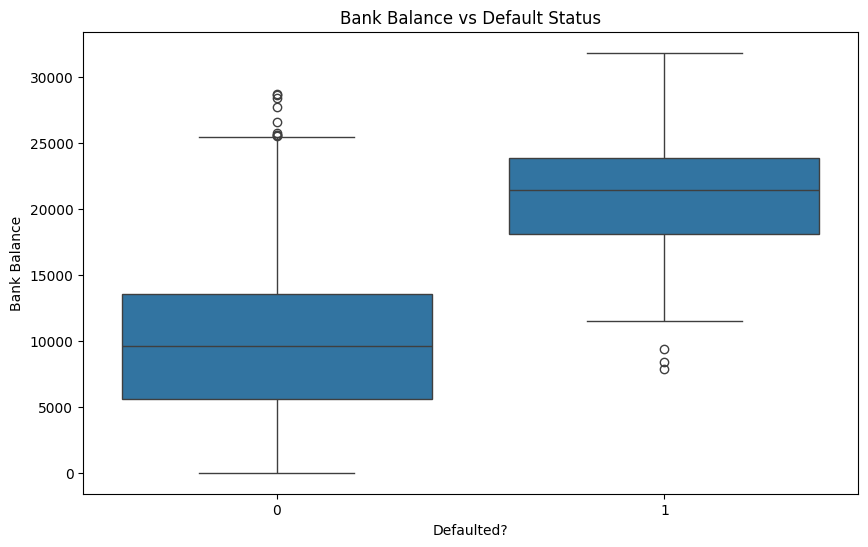

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Defaulted?', y='Bank Balance', data=df)
plt.title('Bank Balance vs Default Status')
plt.show()

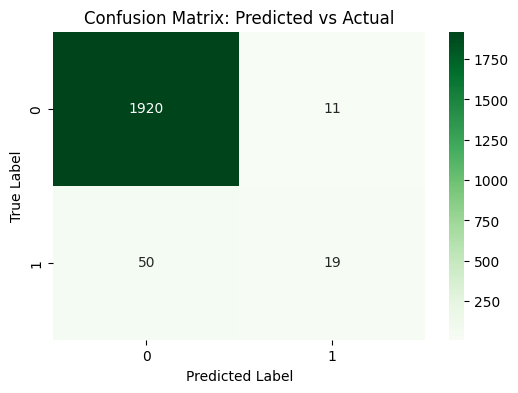

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1931
           1       0.63      0.28      0.38        69

    accuracy                           0.97      2000
   macro avg       0.80      0.63      0.68      2000
weighted avg       0.96      0.97      0.96      2000



In [46]:
from sklearn.metrics import confusion_matrix, classification_report

# Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the Confusion Matrix using a Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.show()

# Print the final report
print(classification_report(y_test, y_pred))